# Machine Learning I (CC2008) - Practical Assignment

---
Trabalho realizado por:

* João Raposo - up202210331
* Rodrigo Coelho - up202208009
* Catarina Aguiar - up202205932

---

## Introdução

De modo a podermos testar o nosso algoritmo, teremos de tratar os datasets que vamos utilizar. Para isso vamos analisar todos os atributos para ver o tipo de dados de cada um, verificar se tem valores nulos, analisar a coluna alvo, verificar se há classes desbalanceadas e, por fim, gerar uma representação gráfica dos dados.

### Bibliotecas necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math

### Alterar definições para que os outputs não saiam truncados

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## Análise dos Datasets

### Dataset_311_oil_splill

**1. Leitura do dataset**

In [3]:
# Leitura do dataset
df_oil = pd.read_csv("untreatedDatasets/dataset_311_oil_spill.csv")

# Visualização de parte dos dados
df_oil.head()

,attr1,attr2,attr3,attr4,attr5,attr6,attr7,attr8,attr9,attr10,attr11,attr12,attr13,attr14,attr15,attr16,attr17,attr18,attr19,attr20,attr21,attr22,attr23,attr24,attr25,attr26,attr27,attr28,attr29,attr30,attr31,attr32,attr33,attr34,attr35,attr36,attr37,attr38,attr39,attr40,attr41,attr42,attr43,attr44,attr45,attr46,attr47,attr48,attr49,class
0,1.0,2558.0,1506.09,456.63,90,6395000.0,40.88,7.89,29780.0,0.19,214.7,0.21,0.26,0.49,0.10,0.40,99.59,32.19,1.84,0.16,0.20,87.65,0,0.47,132.78,-0.01,3.78,0.22,3.20,-3.71,-0.18,2.19,0.0,2.19,310.0,16110.0,0.00,138.68,89,69,2850.00,1000.00,763.16,135.46,3.73,0,33243.19,65.74,7.95,1
1,2.0,22325.0,79.11,841.03,180,55812500.0,51.11,1.21,61900.0,0.02,901.7,0.02,0.03,0.11,0.01,0.11,6058.23,4061.15,2.30,0.02,0.02,87.65,0,0.58,132.78,-0.01,3.78,0.84,7.09,-2.21,0.00,0.00,0.0,0.00,704.0,40140.0,0.00,68.65,89,69,5750.00,11500.00,9593.48,1648.80,0.60,0,51572.04,65.73,6.26,-1
2,3.0,115.0,1449.85,608.43,88,287500.0,40.42,7.34,3340.0,0.18,86.1,0.21,0.32,0.50,0.17,0.34,71.20,16.73,1.82,0.19,0.29,87.65,0,0.46,132.78,-0.01,3.78,0.70,4.79,-3.36,-0.23,1.95,0.0,1.95,29.0,1530.0,0.01,38.80,89,69,1400.00,250.00,150.00,45.13,9.33,1,31692.84,65.81,7.84,1
3,4.0,1201.0,1562.53,295.65,66,3002500.0,42.40,7.97,18030.0,0.19,166.5,0.21,0.26,0.48,0.10,0.38,120.22,33.47,1.91,0.16,0.21,87.65,0,0.48,132.78,-0.01,3.78,0.84,6.78,-3.54,-0.33,2.20,0.0,2.20,183.0,10080.0,0.00,108.27,89,69,6041.52,761.58,453.21,144.97,13.33,1,37696.21,65.67,8.07,1
4,5.0,312.0,950.27,440.86,37,780000.0,41.43,7.03,3350.0,0.17,232.8,0.15,0.19,0.35,0.09,0.26,289.19,48.68,1.86,0.13,0.16,87.65,0,0.47,132.78,-0.01,3.78,0.02,2.28,-3.44,-0.44,2.19,0.0,2.19,45.0,2340.0,0.00,14.39,89,69,1320.04,710.63,512.54,109.16,2.58,0,29038.17,65.66,7.35,-1


Percebemos então que o dataset tem 49 atributos e que "class" é a classe alvo.

**2. Tipo de dados**

Nesta secção verificamos os tipos de dados de cada atributo para verificar se seria necessário converter em valores numéricos.

In [4]:
print(df_oil.dtypes)

attr1     float64
attr2     float64
attr3     float64
attr4     float64
attr5       int64
attr6     float64
attr7     float64
attr8     float64
attr9     float64
attr10    float64
attr11    float64
attr12    float64
attr13    float64
attr14    float64
attr15    float64
attr16    float64
attr17    float64
attr18    float64
attr19    float64
attr20    float64
attr21    float64
attr22    float64
attr23      int64
attr24    float64
attr25    float64
attr26    float64
attr27    float64
attr28    float64
attr29    float64
attr30    float64
attr31    float64
attr32    float64
attr33    float64
attr34    float64
attr35    float64
attr36    float64
attr37    float64
attr38    float64
attr39      int64
attr40      int64
attr41    float64
attr42    float64
attr43    float64
attr44    float64
attr45    float64
attr46      int64
attr47    float64
attr48    float64
attr49    float64
class       int64
dtype: object


Como todos os valores são numéricos, não é necessário converter nada.

**3. Valores nulos**

In [5]:
print(df_oil.isnull().sum())

attr1     0
attr2     0
attr3     0
attr4     0
attr5     0
attr6     0
attr7     0
attr8     0
attr9     0
attr10    0
attr11    0
attr12    0
attr13    0
attr14    0
attr15    0
attr16    0
attr17    0
attr18    0
attr19    0
attr20    0
attr21    0
attr22    0
attr23    0
attr24    0
attr25    0
attr26    0
attr27    0
attr28    0
attr29    0
attr30    0
attr31    0
attr32    0
attr33    0
attr34    0
attr35    0
attr36    0
attr37    0
attr38    0
attr39    0
attr40    0
attr41    0
attr42    0
attr43    0
attr44    0
attr45    0
attr46    0
attr47    0
attr48    0
attr49    0
class     0
dtype: int64


Neste dataset não há valores nulos e, como tal, não será necessário tratar os dados neste sentido.

**4. Análise da coluna alvo**

Vamos normalizar o nome da coluna alvo para "CLASS", verificar quais classes existem, e quantas entradas de cada classe existem.

Valores únicos em CLASS: [ 1 -1]

Resumo da distribuição de classes:
        Contagem  Percentagem (%)
CLASS                           
-1          896             95.6
 1           41              4.4


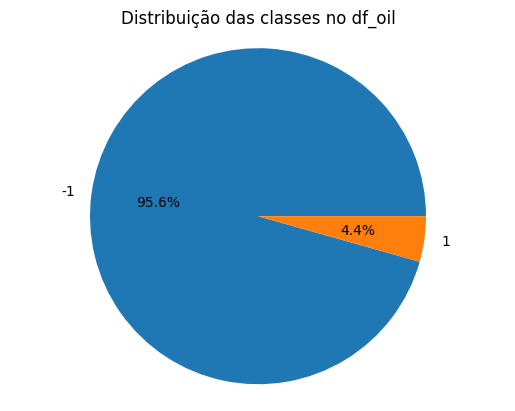

In [6]:
# Normalizar o nome da coluna alvo para "CLASS"
orig_class = next(c for c in df_oil.columns if c == 'class')
df_oil = df_oil.rename(columns={orig_class: 'CLASS'})

# Mostrar os valores únicos em CLASS
print('Valores únicos em CLASS:', df_oil['CLASS'].unique())

# Contabilizar o número de instâncias de cada classe
counts = df_oil['CLASS'].value_counts()
percent = df_oil['CLASS'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Contagem': counts,
    'Percentagem (%)': percent.round(1)
})
print('\nResumo da distribuição de classes:\n', summary)

# Visualizar a distribuição em gráfico circular
plt.figure()
plt.pie(
    counts.values,
    labels=[str(c) for c in counts.index],
    autopct='%1.1f%%'
)
plt.axis('equal')
plt.title('Distribuição das classes no df_oil')
plt.show()

Com isto, concluímos que os este dataset contém classes desbalanceadas.

**5. Visualização dos dados**



Nesta secção vamos ver os dados de uma forma gráfica com scatterplots para cada feature.

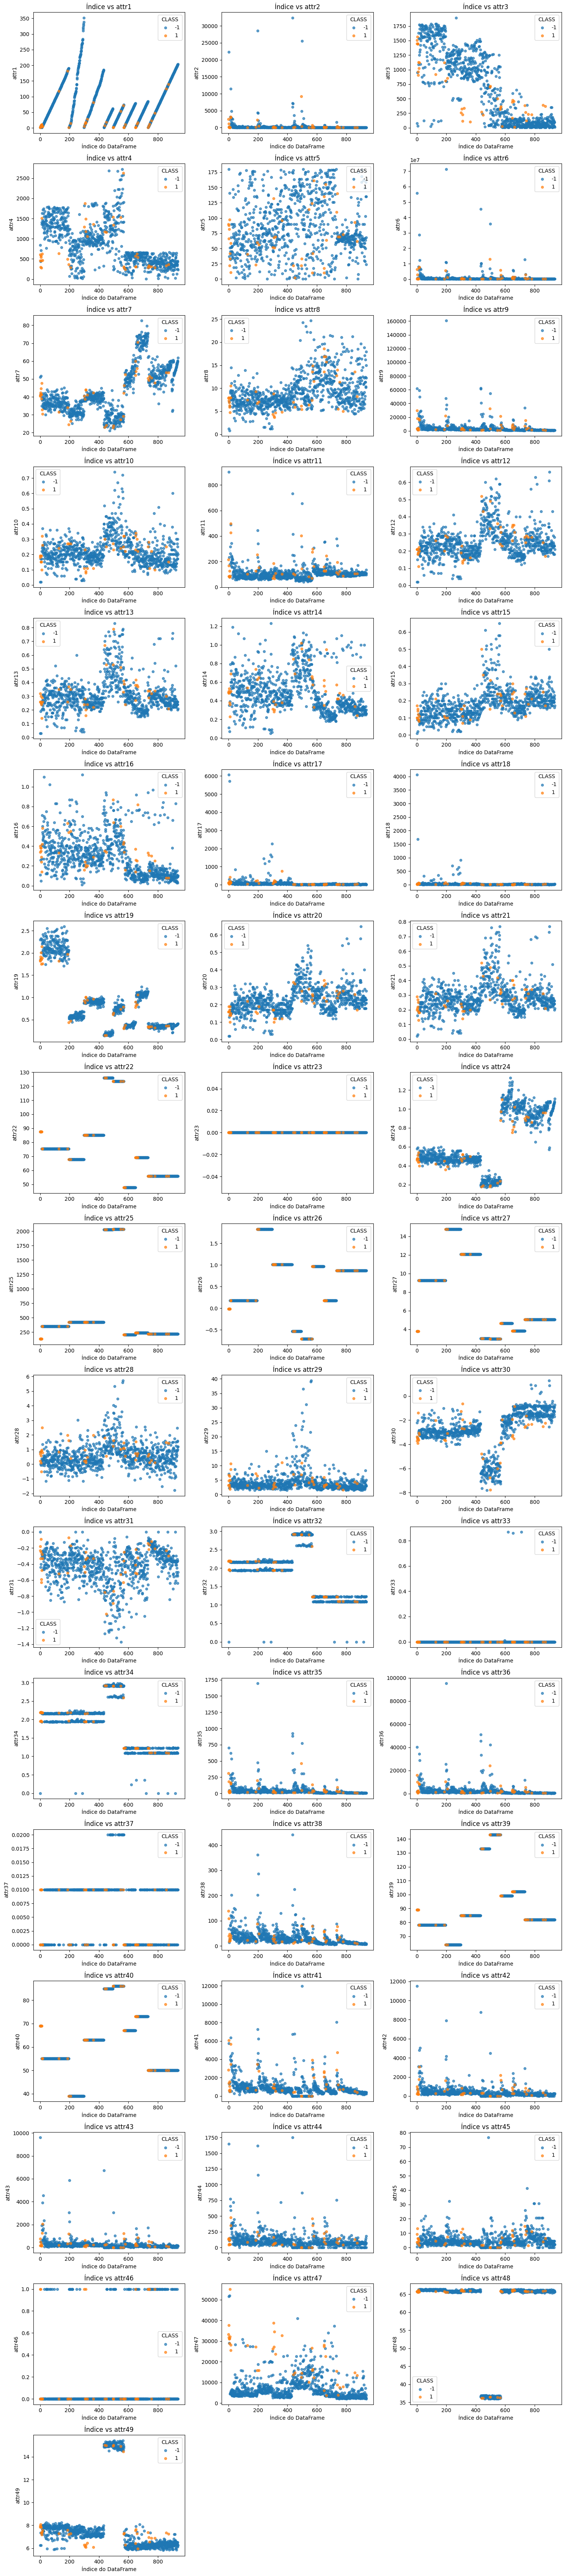

In [7]:
class_col    = 'CLASS'
feature_cols = [c for c in df_oil.columns if c != class_col]

# Definir layout da grelha
n    = len(feature_cols)
cols = 3 
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Criar um scatter plot por feature
for ax, feat in zip(axes, feature_cols):
    for cls in sorted(df_oil[class_col].unique()):
        subset = df_oil[df_oil[class_col] == cls]
        ax.scatter(subset.index, subset[feat],
                   label=str(cls), alpha=0.7, s=20)
    ax.set_xlabel('Índice do DataFrame')
    ax.set_ylabel(feat)
    ax.set_title(f'Índice vs {feat}')
    ax.legend(title='CLASS')

# Remover eixos vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Dataset_767_analcatdata_apnea1

**1. Leitura do dataset**

In [8]:
# Leitura do dataset
df_apnea = pd.read_csv("untreatedDatasets/dataset_767_analcatdata_apnea1.csv")

# Visualização de parte dos dados
df_apnea.head()

,Scorer_1,Scorer_2,Subject,binaryClass
0,N,N,1,N
1,H,N,1,P
2,OA,N,1,P
3,MA,N,1,P
4,CA,N,1,N


**2. Tipos de Dados**

In [9]:
print(df_apnea.dtypes)

Scorer_1       object
Scorer_2       object
Subject         int64
binaryClass    object
dtype: object


Vamos converter os atributos do tipo objeto para valores numéricos.

In [10]:
# Converter colunas de string para numéricas
obj_cols = df_apnea.select_dtypes(include='object').columns
for col in obj_cols:
    df_apnea[col] = pd.factorize(df_apnea[col])[0]

# Verificar tipos após conversão
print('\nTipos após conversão:')
print(df_apnea.dtypes)

print("\nDados normalizados:")

df_apnea.head()


Tipos após conversão:
Scorer_1       int64
Scorer_2       int64
Subject        int64
binaryClass    int64
dtype: object

Dados normalizados:


,Scorer_1,Scorer_2,Subject,binaryClass
0,0,0,1,0
1,1,0,1,1
2,2,0,1,1
3,3,0,1,1
4,4,0,1,0


Os dados são agora numéricos, evitando conflito ao correr o algoritmo.

**3. Valores Nulos**

In [11]:
print(df_apnea.isnull().sum())

Scorer_1       0
Scorer_2       0
Subject        0
binaryClass    0
dtype: int64


**4. Análise da coluna alvo**

Valores únicos em CLASS: [0 1]

Resumo da distribuição de classes:
        Contagem  Percentagem (%)
CLASS                           
1           414             87.2
0            61             12.8


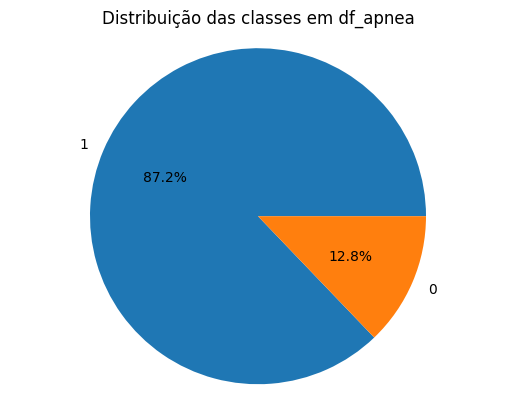

In [12]:
# Normalizar o nome da coluna alvo para "CLASS"
orig_class = df_apnea.columns[-1]
df_apnea = df_apnea.rename(columns={orig_class: 'CLASS'})

# Mostrar os valores únicos em CLASS
print('Valores únicos em CLASS:', df_apnea['CLASS'].unique())

# Contabilizar o número de instâncias de cada classe
counts  = df_apnea['CLASS'].value_counts()
percent = df_apnea['CLASS'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Contagem':        counts,
    'Percentagem (%)': percent.round(1)
})
print('\nResumo da distribuição de classes:\n', summary)

# Visualizar a distribuição em gráfico circular
plt.figure()
plt.pie(
    counts.values,
    labels=[str(c) for c in counts.index],
    autopct='%1.1f%%'
)
plt.axis('equal')
plt.title('Distribuição das classes em df_apnea')
plt.show()

Verificamos que este dataset também tem classes desbalanceadas.

**5. Visualização dos dados**

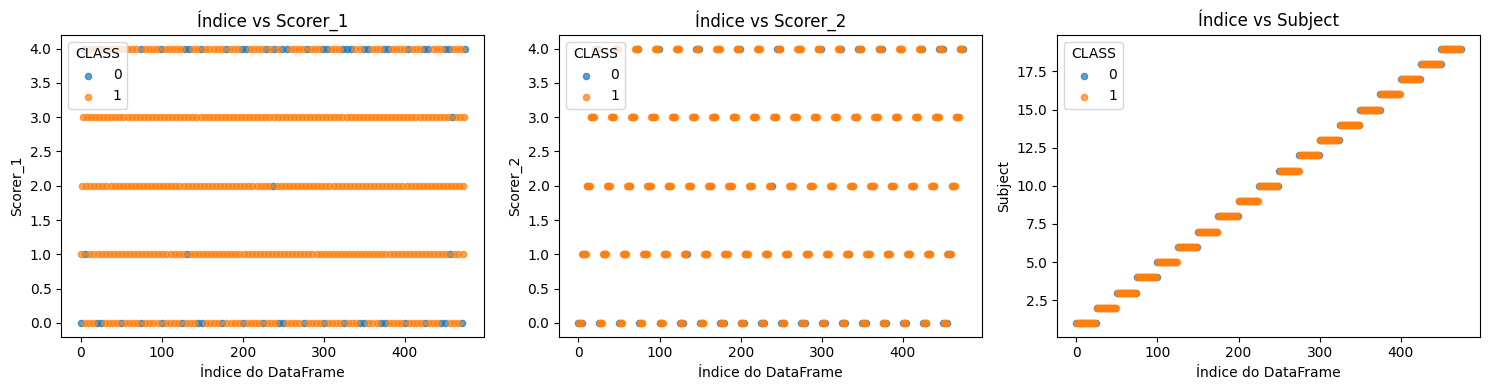

In [13]:
# Visualização dos dados em df_apnea
class_col    = 'CLASS'
feature_cols = [c for c in df_apnea.columns if c != class_col]

# Definir layout da grelha
n    = len(feature_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Criar um scatter plot por feature
for ax, feat in zip(axes, feature_cols):
    for cls in sorted(df_apnea[class_col].unique()):
        subset = df_apnea[df_apnea[class_col] == cls]
        ax.scatter(subset.index, subset[feat],
                   label=str(cls), alpha=0.7, s=20)
    ax.set_xlabel('Índice do DataFrame')
    ax.set_ylabel(feat)
    ax.set_title(f'Índice vs {feat}')
    ax.legend(title='CLASS')

# Remover eixos vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Dataset_947_arsenic-male-bladder

**1. Leitura do dataset**

In [14]:
# Leitura do dataset
df_bladder = pd.read_csv("untreatedDatasets/dataset_947_arsenic-male-bladder.csv")

# Visualização de parte dos dados
df_bladder.head()

,group,conc,age,at.risk,binaryClass
0,1,0.0,22.5,2956638.0,N
1,1,0.0,27.5,2175046.0,N
2,1,0.0,32.5,1580019.0,N
3,1,0.0,37.5,1320637.0,N
4,1,0.0,42.5,1327866.0,N


**2. Tipo de Dados**

In [15]:
print(df_bladder.dtypes)

group            int64
conc           float64
age            float64
at.risk        float64
binaryClass     object
dtype: object


A coluna alvo tem valores não numéricos N para a classe negativa e P para a positiva, o que será alterado na secção 4 para 0 e 1 respetivamente.

**3. Valores nulos**

In [16]:
print(df_bladder.isnull().sum())

group          0
conc           0
age            0
at.risk        0
binaryClass    0
dtype: int64


**4. Análise da coluna alvo**

In [17]:
# Normalizar o nome da coluna alvo para "CLASS"
orig_class = df_bladder.columns[-1]
df_bladder = df_bladder.rename(columns={orig_class: 'CLASS'})

# Normalizar os valores da coluna CLASS
df_bladder['CLASS'] = df_bladder['CLASS'].map({'N': 0, 'P': 1})

Valores únicos em CLASS: [0 1]

Resumo da distribuição de classes:
        Contagem  Percentagem (%)
CLASS                           
1           535             95.7
0            24              4.3


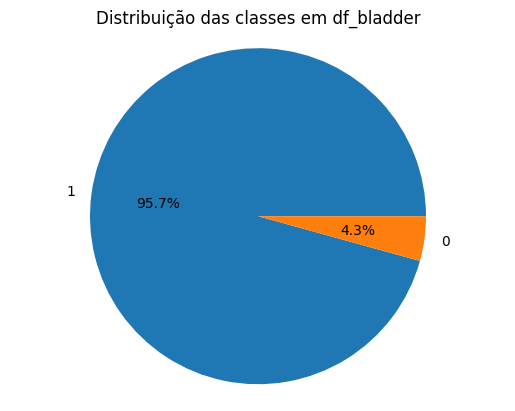

In [18]:
# Mostrar os valores únicos em CLASS
print('Valores únicos em CLASS:', df_bladder['CLASS'].unique())

# Contabilizar o número de instâncias de cada classe
counts  = df_bladder['CLASS'].value_counts()
percent = df_bladder['CLASS'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Contagem':        counts,
    'Percentagem (%)': percent.round(1)
})
print('\nResumo da distribuição de classes:\n', summary)

# Visualizar a distribuição em gráfico circular
plt.figure()
plt.pie(
    counts.values,
    labels=[str(c) for c in counts.index],
    autopct='%1.1f%%'
)
plt.axis('equal')
plt.title('Distribuição das classes em df_bladder')
plt.show()

Verificamos que este dataset também tem classes desbalanceadas.

**5. Visualização dos dados**

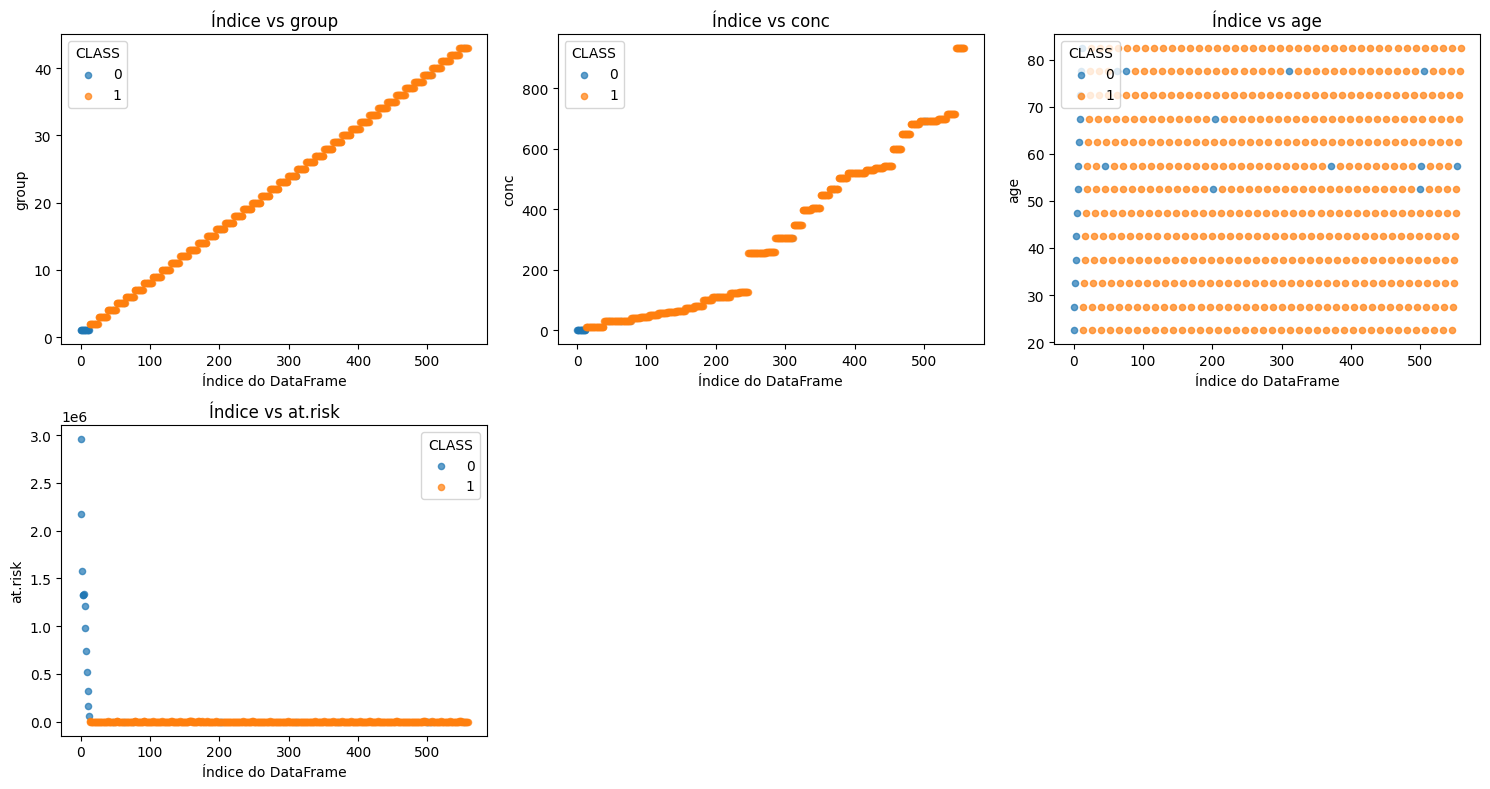

In [19]:
# Visualização dos dados em df_bladder
class_col    = 'CLASS'
feature_cols = [c for c in df_bladder.columns if c != class_col]

# Definir layout da grelha
n    = len(feature_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Criar um scatter plot por feature
for ax, feat in zip(axes, feature_cols):
    for cls in sorted(df_bladder[class_col].unique()):
        subset = df_bladder[df_bladder[class_col] == cls]
        ax.scatter(subset.index, subset[feat],
                   label=str(cls), alpha=0.7, s=20)
    ax.set_xlabel('Índice do DataFrame')
    ax.set_ylabel(feat)
    ax.set_title(f'Índice vs {feat}')
    ax.legend(title='CLASS')

# Remover eixos vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Dataset_1004_synthetic_control

**1. Leitura do dataset**

In [20]:
# Leitura do dataset
df_synthetic = pd.read_csv("untreatedDatasets/dataset_1004_synthetic_control.csv")

# Visualização de parte dos dados
df_synthetic.head()

,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31,col_32,col_33,col_34,col_35,col_36,col_37,col_38,col_39,col_40,col_41,col_42,col_43,col_44,col_45,col_46,col_47,col_48,col_49,col_50,col_51,col_52,col_53,col_54,col_55,col_56,col_57,col_58,col_59,col_60,binaryClass
0,28.7812,34.4632,31.3381,31.2834,28.9207,33.7596,25.3969,27.7849,35.2479,27.1159,32.8717,29.2171,36.0253,32.3370,34.5249,32.8717,34.1173,26.5235,27.6623,26.3693,25.7744,29.2700,30.7326,29.5054,33.0292,25.0400,28.9167,24.3437,26.1203,34.9424,25.0293,26.6311,35.6541,28.4353,29.1495,28.1584,26.1927,33.3182,30.9772,27.0443,35.5344,26.2353,28.9964,32.0036,31.0558,34.2553,28.0721,28.9402,35.4973,29.7470,31.4333,24.5556,33.7431,25.0466,34.9318,34.9879,32.4721,33.3759,25.4652,25.8717,N
1,24.8923,25.7410,27.5532,32.8217,27.8789,31.5926,31.4861,35.5469,27.9516,31.6595,27.5415,31.1887,27.4867,31.3910,27.8110,24.4880,27.5918,35.6273,35.4102,31.4167,30.7447,24.1311,35.1422,30.4719,31.9874,33.6615,25.5511,30.4686,33.6472,25.0701,34.0765,32.5981,28.3038,26.1471,26.9414,31.5203,33.1089,24.1491,28.5157,25.7906,35.9519,26.5301,24.8578,25.9562,32.8357,28.5322,26.3458,30.6213,28.9861,29.4047,32.5577,31.0205,26.6418,28.4331,33.6564,26.4244,28.4661,34.2484,32.1005,26.6910,N
2,31.3987,30.6316,26.3983,24.2905,27.8613,28.5491,24.9717,32.4358,25.2239,27.3068,31.8387,27.2587,28.2572,26.5819,24.0455,35.0625,31.5717,32.5614,31.0308,34.1202,26.9337,31.4781,35.0173,32.3851,24.3323,30.2001,31.2452,26.6814,31.5137,28.8778,27.3086,24.2460,26.9631,25.2919,31.6114,24.7131,27.4809,24.2075,26.8059,35.1253,32.6293,31.0561,26.3583,28.0861,31.4391,27.3057,29.6082,35.9725,34.1444,27.1717,33.6318,26.5966,25.5387,32.5434,25.5772,29.9897,31.3510,33.9002,29.5446,29.3430,N
3,25.7740,30.5262,35.4209,25.6033,27.9700,25.2702,28.1320,29.4268,31.4549,27.3200,28.9564,28.9916,29.9578,30.2773,30.4447,24.3037,24.3140,35.0966,25.3679,32.0968,33.3303,25.0102,35.3155,31.6264,29.2806,34.2021,26.5077,32.2279,25.5265,24.8240,27.5587,28.3714,32.3667,26.9752,35.9346,35.1146,24.3749,27.6083,27.8433,29.8557,32.4185,26.8908,31.3209,29.3849,34.3336,24.7381,35.7690,31.8725,34.2054,31.1560,34.6292,28.7261,28.2979,31.5787,34.6156,32.5492,30.9827,24.8938,27.3659,25.3069,N
4,27.1798,29.2498,33.6928,25.6264,24.6555,28.9446,35.7980,34.9446,24.5596,34.2366,27.9634,25.3216,35.4154,34.8620,25.1472,29.4686,33.1739,31.1274,31.3701,26.5173,28.6486,31.6565,35.9497,33.0321,24.6081,33.2025,27.4335,32.6355,35.8773,28.0295,33.1247,33.4129,26.9245,30.2123,29.6526,30.8644,24.5119,33.9931,33.3094,33.2040,31.2651,27.9072,35.1110,35.0757,33.8330,25.9481,29.1348,24.2875,32.3223,34.9244,27.7218,27.9601,35.7198,27.5760,35.3375,29.9993,34.2149,33.1276,31.1057,31.0179,N


**2. Tipo de dados**

In [21]:
print(df_synthetic.dtypes)

col_1          float64
col_2          float64
col_3          float64
col_4          float64
col_5          float64
col_6          float64
col_7          float64
col_8          float64
col_9          float64
col_10         float64
col_11         float64
col_12         float64
col_13         float64
col_14         float64
col_15         float64
col_16         float64
col_17         float64
col_18         float64
col_19         float64
col_20         float64
col_21         float64
col_22         float64
col_23         float64
col_24         float64
col_25         float64
col_26         float64
col_27         float64
col_28         float64
col_29         float64
col_30         float64
col_31         float64
col_32         float64
col_33         float64
col_34         float64
col_35         float64
col_36         float64
col_37         float64
col_38         float64
col_39         float64
col_40         float64
col_41         float64
col_42         float64
col_43         float64
col_44     

A coluna alvo tem valores não numéricos N para a classe negativa e P para a positiva, o que será alterado na secção 4 para 0 e 1 respetivamente.

**3. Valores Nulos**

In [22]:
print(df_synthetic.isnull().sum())

col_1          0
col_2          0
col_3          0
col_4          0
col_5          0
col_6          0
col_7          0
col_8          0
col_9          0
col_10         0
col_11         0
col_12         0
col_13         0
col_14         0
col_15         0
col_16         0
col_17         0
col_18         0
col_19         0
col_20         0
col_21         0
col_22         0
col_23         0
col_24         0
col_25         0
col_26         0
col_27         0
col_28         0
col_29         0
col_30         0
col_31         0
col_32         0
col_33         0
col_34         0
col_35         0
col_36         0
col_37         0
col_38         0
col_39         0
col_40         0
col_41         0
col_42         0
col_43         0
col_44         0
col_45         0
col_46         0
col_47         0
col_48         0
col_49         0
col_50         0
col_51         0
col_52         0
col_53         0
col_54         0
col_55         0
col_56         0
col_57         0
col_58         0
col_59        

**4. Análise da coluna alvo**

In [23]:
# Normalizar o nome da coluna alvo para "CLASS"
orig_class = df_synthetic.columns[-1]
df_synthetic = df_synthetic.rename(columns={orig_class: 'CLASS'})

# Normalizar os valores da coluna CLASS
df_synthetic['CLASS'] = df_synthetic['CLASS'].map({'N': 0, 'P': 1})

Valores únicos em CLASS: [0 1]

Resumo da distribuição de classes:
        Contagem  Percentagem (%)
CLASS                           
0           500             83.3
1           100             16.7


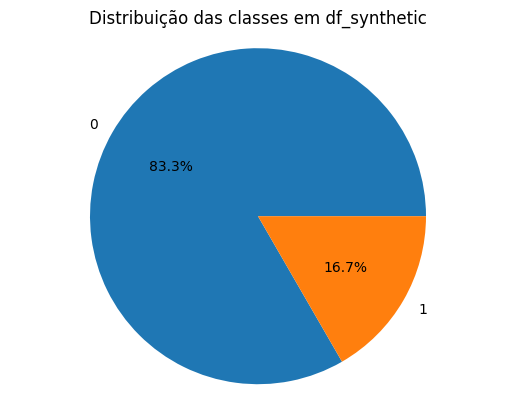

In [24]:
# Mostrar os valores únicos em CLASS
print('Valores únicos em CLASS:', df_synthetic['CLASS'].unique())

# Contabilizar o número de instâncias de cada classe
counts  = df_synthetic['CLASS'].value_counts()
percent = df_synthetic['CLASS'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Contagem':        counts,
    'Percentagem (%)': percent.round(1)
})
print('\nResumo da distribuição de classes:\n', summary)

# Visualizar a distribuição em gráfico circular
plt.figure()
plt.pie(
    counts.values,
    labels=[str(c) for c in counts.index],
    autopct='%1.1f%%'
)
plt.axis('equal')
plt.title('Distribuição das classes em df_synthetic')
plt.show()

Verificamos que este dataset também tem classes desbalanceadas.

**5. Visualização dos dados**

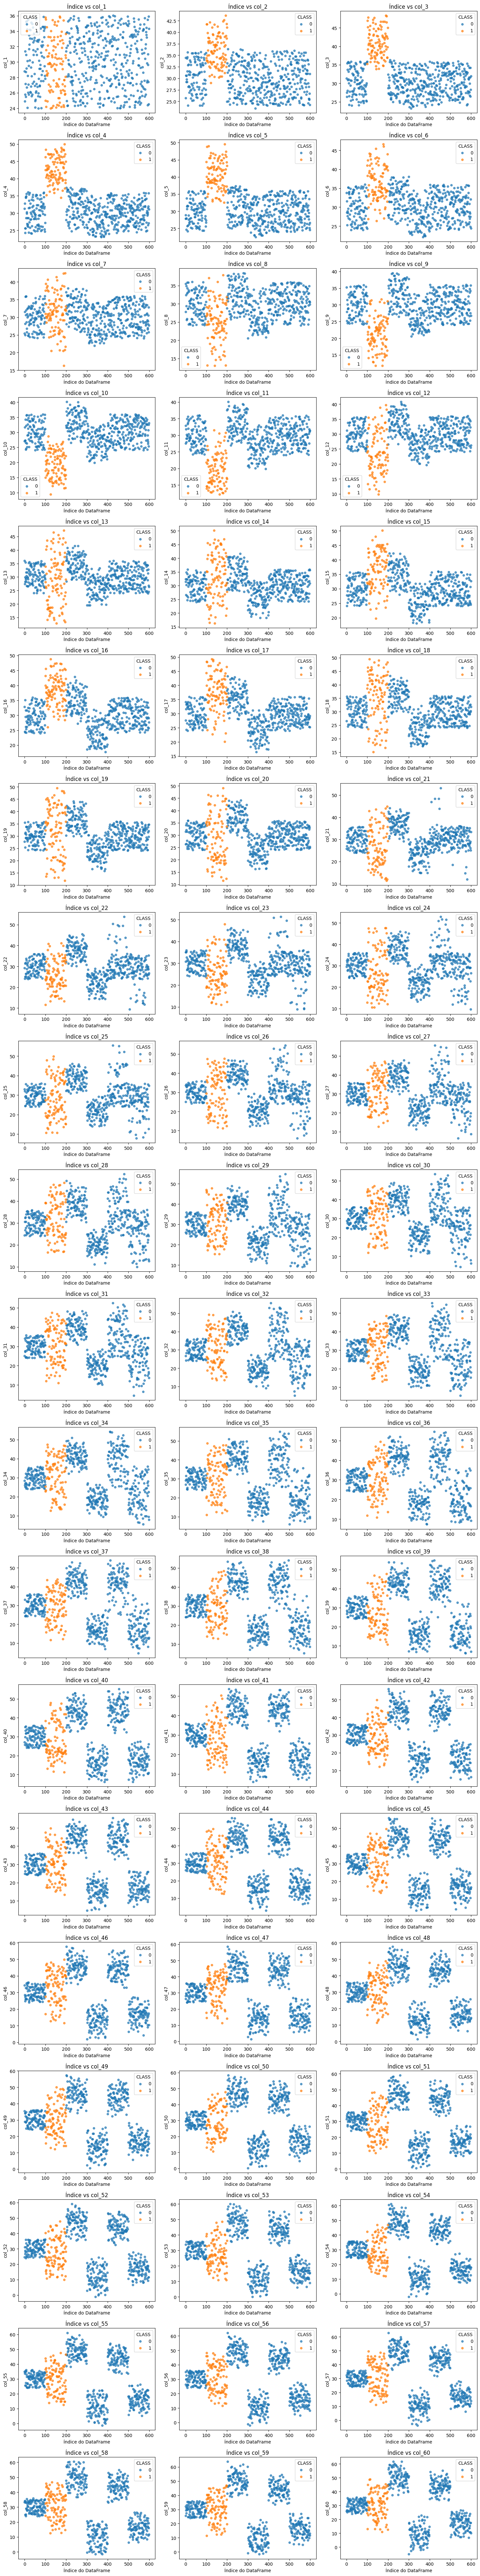

In [25]:
# Visualização dos dados em df_synthetic
class_col    = 'CLASS'
feature_cols = [c for c in df_synthetic.columns if c != class_col]

# Definir layout da grelha
n    = len(feature_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Criar um scatter plot por feature
for ax, feat in zip(axes, feature_cols):
    for cls in sorted(df_synthetic[class_col].unique()):
        subset = df_synthetic[df_synthetic[class_col] == cls]
        ax.scatter(subset.index, subset[feat],
                   label=str(cls), alpha=0.7, s=20)
    ax.set_xlabel('Índice do DataFrame')
    ax.set_ylabel(feat)
    ax.set_title(f'Índice vs {feat}')
    ax.legend(title='CLASS')

# Remover eixos vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Dataset_1014_analcatdata_dmft

**1. Leitura do dataset**

In [26]:
# Leitura do dataset
df_dmtf = pd.read_csv("untreatedDatasets/dataset_1014_analcatdata_dmft.csv")

# Visualização de parte dos dados
df_dmtf.head()

,DMFT.Begin,DMFT.End,Gender,Ethnic,binaryClass
0,6,3,Male,Black,N
1,2,1,Female,Black,N
2,1,0,Male,Black,N
3,7,2,Male,White,N
4,3,3,Female,White,N


**2. Tipos de dados**

In [27]:
print(df_dmtf.dtypes)

DMFT.Begin      int64
DMFT.End        int64
Gender         object
Ethnic         object
binaryClass    object
dtype: object


Vamos alterar os dados do tipo object para inteiros.

In [28]:
# Converter colunas de string para numéricas
obj_cols = df_dmtf.select_dtypes(include='object').columns
for col in obj_cols:
    if col != 'binaryClass':
        df_dmtf[col] = pd.factorize(df_dmtf[col])[0]

# Verificar tipos após conversão
print('\nTipos após conversão:')
print(df_dmtf.dtypes)

print("\nDados normalizados:")

df_dmtf.head()


Tipos após conversão:
DMFT.Begin      int64
DMFT.End        int64
Gender          int64
Ethnic          int64
binaryClass    object
dtype: object

Dados normalizados:


,DMFT.Begin,DMFT.End,Gender,Ethnic,binaryClass
0,6,3,0,0,N
1,2,1,1,0,N
2,1,0,0,0,N
3,7,2,0,1,N
4,3,3,1,1,N


A coluna alvo tem valores não numéricos N para a classe negativa e P para a positiva, o que será alterado na secção 4 para 0 e 1 respetivamente.

**3. Valores Nulos**

In [29]:
print(df_dmtf.isnull().sum())

DMFT.Begin     0
DMFT.End       0
Gender         0
Ethnic         0
binaryClass    0
dtype: int64


**4. Análise da coluna alvo**

In [30]:
# Normalizar o nome da coluna alvo para "CLASS"
orig_class = df_dmtf.columns[-1]
df_dmtf = df_dmtf.rename(columns={orig_class: 'CLASS'})

# Normalizar os valores da coluna CLASS
df_dmtf['CLASS'] = df_dmtf['CLASS'].map({'N': 0, 'P': 1})

Valores únicos em CLASS: [0 1]

Resumo da distribuição de classes:
        Contagem  Percentagem (%)
CLASS                           
0           642             80.6
1           155             19.4


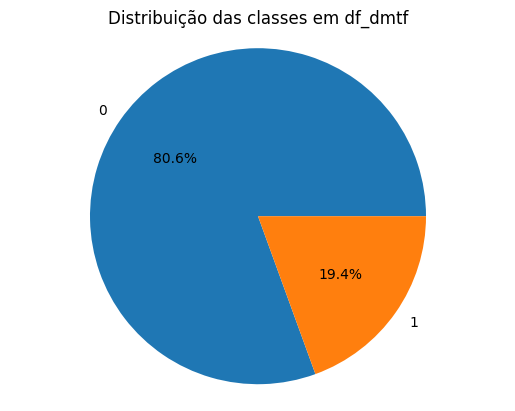

In [31]:
# Mostrar os valores únicos em CLASS
print('Valores únicos em CLASS:', df_dmtf['CLASS'].unique())

# Contabilizar o número de instâncias de cada classe
counts  = df_dmtf['CLASS'].value_counts()
percent = df_dmtf['CLASS'].value_counts(normalize=True) * 100
summary = pd.DataFrame({
    'Contagem':        counts,
    'Percentagem (%)': percent.round(1)
})
print('\nResumo da distribuição de classes:\n', summary)

# Visualizar a distribuição em gráfico circular
plt.figure()
plt.pie(
    counts.values,
    labels=[str(c) for c in counts.index],
    autopct='%1.1f%%'
)
plt.axis('equal')
plt.title('Distribuição das classes em df_dmtf')
plt.show()

Verificamos que este dataset também tem classes desbalanceadas.

**5. Visualização dos dados**

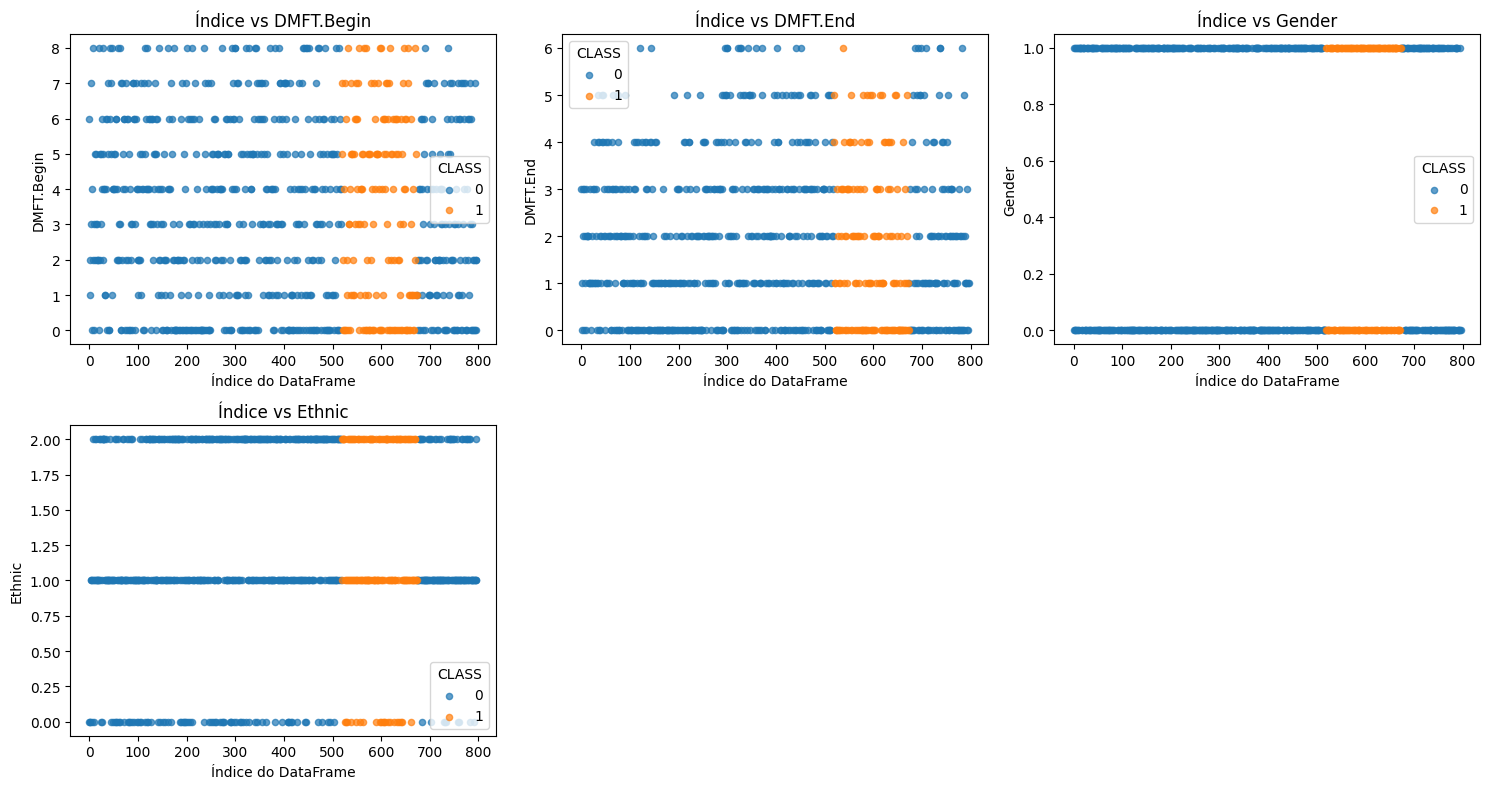

In [32]:
# Visualização dos dados em df_dmtf
class_col    = 'CLASS'
feature_cols = [c for c in df_dmtf.columns if c != class_col]

# Definir layout da grelha
n    = len(feature_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Criar um scatter plot por feature
for ax, feat in zip(axes, feature_cols):
    for cls in sorted(df_dmtf[class_col].unique()):
        subset = df_dmtf[df_dmtf[class_col] == cls]
        ax.scatter(subset.index, subset[feat],
                   label=str(cls), alpha=0.7, s=20)
    ax.set_xlabel('Índice do DataFrame')
    ax.set_ylabel(feat)
    ax.set_title(f'Índice vs {feat}')
    ax.legend(title='CLASS')

# Remover eixos vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

## Conclusão da limpeza dos dados

Depois desta inspeção aos dataframes selecionados e à resolução das inconsistências, obtivemos tabelas limpas. No entanto, todas apresentam uma distribuição desequilibrada na variável target, o que se configura como o principal desafio a ser enfrentado.

Com isso, só falta exportar os dados tratados para ficheiros .csv, que serão utilizados ao longo do projeto:

In [33]:
# Após a limpeza e normalização, salvar os DataFrames tratados em arquivos CSV
df_oil.to_csv('cleanDatasets/oil.csv', index=False)
df_apnea.to_csv('cleanDatasets/apnea.csv', index=False)
df_bladder.to_csv('cleanDatasets/bladder.csv', index=False)
df_synthetic.to_csv('cleanDatasets/synthetic.csv', index=False)
df_dmtf.to_csv('cleanDatasets/dmtf.csv', index=False)